In [9]:
import sys, os, pathlib
sys.path.append("/root/shared/gitrepos/smart-mechanotransduction/utils")
sys.path.append("/root/shared/gitrepos/smart-comp-sci/mechanotransduction-example")
cur_dir = str(pathlib.Path.cwd() / "..")
import smart_analysis
from matplotlib import pyplot as plt
import matplotlib
plt.style.use(f"{cur_dir}/plotting/smart_plots.mplstyle")
matplotlib.rcParams.update({'figure.figsize': (5,4)})
import numpy as np
import dolfin as d
import h5py

In [2]:
import warnings
from matplotlib.collections import LineCollection

def colored_line(x, y, c, ax, **lc_kwargs):
    """
    Plot a line with a color specified along the line by a third value.

    It does this by creating a collection of line segments. Each line segment is
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should be the same size as x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')

    # Default the capstyle to butt so that the line segments smoothly line up
    default_kwargs = {"capstyle": "butt"}
    default_kwargs.update(lc_kwargs)

    # Compute the midpoints of the line segments. Include the first and last points
    # twice so we don't need any special syntax later to handle them.
    x = np.asarray(x)
    y = np.asarray(y)
    x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
    y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))

    # Determine the start, middle, and end coordinate pair of each line segment.
    # Use the reshape to add an extra dimension so each pair of points is in its
    # own list. Then concatenate them to create:
    # [
    #   [(x1_start, y1_start), (x1_mid, y1_mid), (x1_end, y1_end)],
    #   [(x2_start, y2_start), (x2_mid, y2_mid), (x2_end, y2_end)],
    #   ...
    # ]
    coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
    coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
    coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
    segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

    lc = LineCollection(segments, **default_kwargs)
    lc.set_array(c)  # set the colors of each segment

    return ax.add_collection(lc)

/tmp/ipykernel_1477846/3843301989.py:88: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ulin.vector().set_local(cur_array[dof_map])
/tmp/ipykernel_1477846/3843301989.py:90: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  alin.vector().set_local(a_array[dof_map])
/tmp/ipykernel_1477846/3843301989.py:92: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  stresslin.vector().set_local(stress_array[dof_map])


Building point search tree to accelerate distance queries.
Computed bounding box tree with 49953 nodes for 24977 points.
966.0297238607455


/tmp/ipykernel_1477846/3843301989.py:88: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ulin.vector().set_local(cur_array[dof_map])
/tmp/ipykernel_1477846/3843301989.py:90: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  alin.vector().set_local(a_array[dof_map])
/tmp/ipykernel_1477846/3843301989.py:92: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  stresslin.vector().set_local(stress_array[dof_map])


1220.1883368418287


/tmp/ipykernel_1477846/3843301989.py:88: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ulin.vector().set_local(cur_array[dof_map])
/tmp/ipykernel_1477846/3843301989.py:90: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  alin.vector().set_local(a_array[dof_map])
/tmp/ipykernel_1477846/3843301989.py:92: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  stresslin.vector().set_local(stress_array[dof_map])


1677.6212194890766


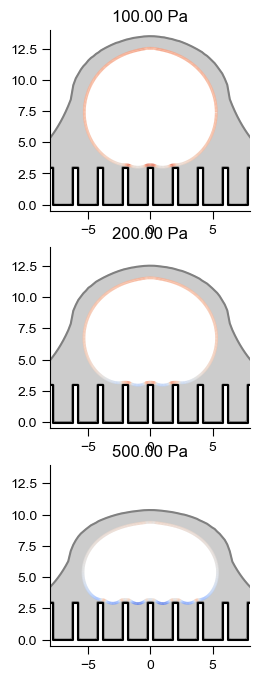

In [8]:
# mesh_num = 2
# pitchList = [5.0, 2.5, 1.0, 5.0, 2.5, 2.5] # last one is fake...
# heightList =[1.0, 1.0, 1.0, 1.0, 1.0, 0.0]
# radList = [0.1, 0.1, 0.1, 0.5, 0.25, 0.25] # last one is fake...
rNP = 0.2#radList[mesh_num]
pNP  = 2.0#6.0#pitchList[mesh_num]
hNP = 3.0#3.0#heightList[mesh_num]
results_folder = f"/root/scratch/new_nuconly_sims/results_nanopillars_nuconly_2026-01-29_sweep/nucmech_nanopillars_h{hNP}_p{pNP}_r{rNP}"
# results_folder = f"/root/scratch/new_nuconly_sims/results_nanopillars_nuconly_2026-01-29_sweep/nucmech_flat"
# results_folder = "/root/shared/gitrepos/nuc_indent_testInner_largeNP"
test_mesh_file = d.XDMFFile(f"{results_folder}/u_np_ellipsoid.xdmf")
test_mesh = d.Mesh()
test_mesh_file.read(test_mesh)

test_file_ulin = f"{results_folder}/ulin_np_ellipsoid.h5"
test_file_alin = f"{results_folder}/a_np_ellipsoid.h5"#surf_stress.h5"
test_file_stresslin = f"{results_folder}/surf_stress.h5"
# test_file_y = f"{results_folder}/uylin_np_ellipsoid.h5"
# test_file_z = f"{results_folder}/uzlin_np_ellipsoid.h5"

Vtest = d.VectorFunctionSpace(test_mesh, "P", 1)
ulin = d.Function(Vtest)
alin = d.Function(Vtest)
stresslin = d.Function(Vtest)
# Vtest = d.FunctionSpace(test_mesh, "P", 1)
# ux = d.Function(Vtest)
# uy = d.Function(Vtest)
# uz = d.Function(Vtest)
xSubstrate = np.array([])
ySubstrate = np.array([])
xSteric = 0.2
zShift = hNP + xSteric
if hNP == 0:
    xMax = 8.5
    xSubstrate = np.array([-xMax,xMax])
    ySubstrate = np.array([hNP,hNP])
else:
    xMax = np.ceil(8.5/pNP) * pNP
    xNP = np.arange(-xMax, xMax+pNP, pNP)
    for i in range(len(xNP)):
        xCur = xNP[i] + np.array([-rNP, -rNP, rNP, rNP])
        yCur = np.array([0.0, hNP, hNP, 0.0])
        xSubstrate = np.append(xSubstrate, xCur)
        ySubstrate = np.append(ySubstrate, yCur)

pRamp = np.loadtxt(f"{results_folder}/pRamp.txt")
kRamp = np.loadtxt(f"{results_folder}/kRamp.txt")

forces = [100.0, 200.0, 500.0]# 300.0, 600.0, 900.0]
indices = []#[np.nonzero(kRamp==0.0)[0][-1]]
for i in range(len(forces)):
    indices.append(np.argmin(np.abs(kRamp-forces[i])))
# indices = indices[1::]
fig, ax = plt.subplots(len(indices),1,figsize=(4,8))
# fig, ax = plt.subplots(1,len(indices),figsize=(8,4))
# fig, ax = plt.subplots(1,len(indices),figsize=(12,6))

for idx in range(len(indices)):#, 5, 10, 20, 50, 100, 175, 250]:
    i = indices[idx]
    # vecs = []
    # for file_name in [test_file_x, test_file_y, test_file_z]:
    #     cur_file = d.HDF5File(d.MPI.comm_world, file_name, "r")
    #     cur_array = d.Vector()
    #     cur_file.read(cur_array, f"VisualisationVector/{i}", True)
    #     cur_file.close()
    #     vecs.append(cur_array[:])
    cur_file = h5py.File(test_file_ulin, 'r')#d.HDF5File(d.MPI.comm_world, test_file_ulin, "r")
    # cur_array = d.Vector()
    # cur_file.read(cur_array, f"VisualisationVector/{i}", True)
    cur_array = cur_file['VisualisationVector'][f'{i}'][()]
    cur_array = cur_array.reshape((3*len(test_mesh.coordinates()),1))
    cur_file.close()

    a_file = h5py.File(test_file_alin, 'r')#d.HDF5File(d.MPI.comm_world, test_file_ulin, "r")
    # cur_array = d.Vector()
    # cur_file.read(cur_array, f"VisualisationVector/{i}", True)
    a_array = a_file['VisualisationVector'][f'{i}'][()]
    a_array = a_array.reshape((3*len(test_mesh.coordinates()),1))
    a_file.close()

    stress_file = h5py.File(test_file_stresslin, 'r')#d.HDF5File(d.MPI.comm_world, test_file_ulin, "r")
    stress_array = stress_file['VisualisationVector'][f'{i}'][()]
    stress_array = stress_array.reshape((3*len(test_mesh.coordinates()),1))
    stress_file.close()

    dof_map = d.dof_to_vertex_map(Vtest)[:]
    # array matches mesh ordering; reorder according to dof mapping for Vcur
    ulin.vector().set_local(cur_array[dof_map])
    ulin.vector().apply("insert")
    alin.vector().set_local(a_array[dof_map])
    alin.vector().apply("insert")
    stresslin.vector().set_local(stress_array[dof_map])
    stresslin.vector().apply("insert")
    # ux.vector().set_local(vecs[0][dof_map])
    # ux.vector().apply("insert")
    # uy.vector().set_local(vecs[1][dof_map])
    # uy.vector().apply("insert")
    # uz.vector().set_local(vecs[2][dof_map])
    # uz.vector().apply("insert")

    zMax = np.max(test_mesh.coordinates()[:,2])
    zMin = np.min(test_mesh.coordinates()[:,2])
    rMax = np.max(np.sqrt(test_mesh.coordinates()[:,0]**2 + 
                        test_mesh.coordinates()[:,1]**2))
    aNuc = rMax
    zNuc = (zMax+zMin)/2
    bNuc = (zMax-zMin)/2
    assert np.abs(aNuc-bNuc) < 1e-4

    ulin.set_allow_extrapolation(True)
    alin.set_allow_extrapolation(True)
    # uy.set_allow_extrapolation(True)
    # uz.set_allow_extrapolation(True)
    theta_sample = np.linspace(0.0, 2*np.pi, 500)
    rvals = np.zeros_like(theta_sample)
    zvals = np.zeros_like(theta_sample)
    avals = np.zeros_like(theta_sample)
    rmidvals = np.zeros_like(theta_sample)
    zmidvals = np.zeros_like(theta_sample)
    stressvals = np.zeros_like(theta_sample)
    stressvals_alt = np.zeros_like(theta_sample)
    for i in range(len(theta_sample)):
        rCur = bNuc*np.cos(theta_sample[i])
        rCurCalc = np.abs(rCur)
        zCur = zNuc + bNuc*np.sin(theta_sample[i])
        uCur = ulin(rCurCalc, 0.0, zCur)
        # uzCur = uz(rCurCalc, 0.0, zCur)
        rvals[i] = rCur + np.sign(rCur)*uCur[0]
        zvals[i] = zCur + uCur[2]
        thickness = 0.2
        rCur_aCalc = np.abs((bNuc-thickness)*np.cos(theta_sample[i]))
        zCur_aCalc = zNuc + (bNuc-thickness)*np.sin(theta_sample[i])
        avals[i] = np.sqrt(np.sum((alin(rCur_aCalc, 0.0, zCur_aCalc))**2))
        rCur_stressCalc = np.abs((bNuc-3*thickness/4)*np.cos(theta_sample[i]))
        zCur_stressCalc = zNuc + (bNuc-3*thickness/4)*np.sin(theta_sample[i])
        rmidCur = (bNuc-thickness/2)*np.cos(theta_sample[i])
        rmidCurCalc = np.abs(rmidCur)
        zmidCur = zCur_stressCalc
        umidCur = ulin(rmidCurCalc, 0.0, zmidCur)
        rmidvals[i] = rmidCur + np.sign(rmidCur)*umidCur[0]
        zmidvals[i] = zCur_stressCalc + umidCur[2]
        stressvals[i] = np.sqrt(np.sum((stresslin(rCur_stressCalc, 0.0, zCur_stressCalc))**2))
        stressvals_alt[i] = np.sqrt(np.sum((stresslin(rCur_aCalc, 0.0, zCur_aCalc))**2))
    
    if hNP == 0:
        rvalsPM = np.array([0.0, 2*rMax])
        zvalsPM = np.array([hNP, hNP])
    else:
        rvalsPM = np.array([0.0])
        zvalsPM = np.array([hNP])
        while rvalsPM[-1] < 2*rMax:
            rStart = rvalsPM[-1]
            thetaDown1 = np.linspace(0.0, np.pi/2, 10)
            rCurvDown1 = rStart + rNP + 0.05*np.sin(thetaDown1)
            zCurvDown1 = hNP + 0.05*(np.cos(thetaDown1)-1)
            thetaDown2 = np.linspace(np.pi/2, 0.0, 10)
            rCurvDown2 = rStart + rNP + 0.05 + 0.2*(1-np.sin(thetaDown2))
            zCurvDown2 = 0.2*(1-np.cos(thetaDown2))
            thetaUp1 = np.linspace(0.0, -np.pi/2, 10)
            rCurvUp1 = rStart+pNP - rNP - 0.05 - 0.2*(1+np.sin(thetaUp1))
            zCurvUp1 = 0.2*(1-np.cos(thetaUp1))
            thetaUp2 = np.linspace(-np.pi/2, 0.0, 10)
            rCurvUp2 = rStart+pNP - rNP + 0.05*np.sin(thetaUp2)
            zCurvUp2 = hNP + 0.05*(np.cos(thetaUp2)-1)

            rvalsPM = np.concatenate((rvalsPM, rCurvDown1, rCurvDown2, rCurvUp1, rCurvUp2, np.array([rStart+pNP])))
            zvalsPM = np.concatenate((zvalsPM, zCurvDown1, zCurvDown2, zCurvUp1, zCurvUp2, np.array([hNP])))
    rvalsPM = np.concatenate((-rvalsPM[-1::-1], rvalsPM))
    zvalsPM = np.concatenate((zvalsPM[-1::-1], zvalsPM))
    rFake = np.linspace(np.min(rvalsPM), np.max(rvalsPM), 100)
    startSample = np.argmax(rvals)
    endSample = np.argmin(rvals)
    zFake = np.zeros_like(rFake)
    for i in range(len(rFake)):
        avgWindowHalf = 10
        if startSample < endSample:
            curSample = np.argmin(np.abs(rFake[i]-1.2*rvals[startSample+1:endSample]))
            zFake[i] = zvals[curSample+startSample+1] +zShift + 1
            avgIdx = range(curSample+startSample+1-avgWindowHalf,
                           curSample+startSample+2+avgWindowHalf)
        else:
            curSample = np.argmin(np.abs(rFake[i]-1.2*np.concatenate((rvals[0:endSample], rvals[startSample:]))))
            if curSample < endSample:
                zFake[i] = zvals[curSample] + zShift + 1
                avgIdx = range(curSample-avgWindowHalf,curSample+1+avgWindowHalf)
            else:
                zFake[i] = zvals[curSample-endSample+startSample] + zShift + 1
                avgIdx = range(curSample-endSample+startSample-avgWindowHalf,
                               curSample-endSample+startSample+1+avgWindowHalf)
        if np.abs(rFake[i]) < 5*rNP:
            zFake[i] = np.average(zvals[avgIdx]) + zShift + 1
        elif np.abs(rFake[i]) > 1.2*np.max(rvals):
            zlin = zFake[i]*(1 - (np.abs(rFake[i])-1.2*np.max(rvals))/8)
            zFake[i] = ((zFake[i] + zlin)/2)*(4/(4+np.abs(rFake[i])-1.2*np.max(rvals)))
    rvalsPM = np.concatenate((rFake[-1::-1], rvalsPM))
    zvalsPM = np.concatenate((zFake[-1::-1], zvalsPM))

    ax[idx].plot(rvalsPM, zvalsPM, linewidth=1.5, color=[0.5,0.5,0.5])
    ax[idx].fill(rvalsPM, zvalsPM, color=[0.8,0.8,0.8])
    ax[idx].plot(xSubstrate, ySubstrate-0.05, color='k', linewidth=1.5)
    ax[idx].fill(rvals, zvals+zShift, color='w')
    line = colored_line(rvals, zvals+zShift, avals, ax[idx], linewidth=2, cmap='coolwarm')
    # line = colored_line(rvals, zvals+zShift, np.ones_like(stressvals), ax[idx], linewidth=1, cmap='coolwarm')
    # line = colored_line(rmidvals, zmidvals+zShift, stressvals, ax[idx], linewidth=1, cmap='coolwarm')

    # ax[idx].plot(rvals, zvals)
    line.set_clim([1, 2])#10000])
    # line.set_clim([0.0, 2000])
    # line = colored_line(rvals, zvals+zShift, stressvals, ax[idx], linewidth=2, cmap='coolwarm')
    ax[idx].set_xlim([-8, 8])
    ax[idx].set_ylim([-0.5, 14])
    # ax[idx].set_xlim([-1, 1])
    # ax[idx].set_ylim([-0.1, 1])
    ax[idx].set_aspect("equal")
    ax[idx].set_title(f"{kRamp[indices[idx]]:.2f} Pa")
    # print(min(avals))
    # print(max(avals))
    print(np.average(stressvals))

# plt.colorbar(line)
plt.savefig(f"nuc_indent_r{rNP}_p{pNP}_h{hNP}.pdf", format="pdf")

In [ ]:
from matplotlib import font_manager
font_files = font_manager.findSystemFonts(fontpaths=None, fontext="ttf")
print(font_files)

In [ ]:
matplotlib.rcParams.update({'figure.figsize': (6,3)})
tvec = np.linspace(0.0, 500.0, 100)
force = 300.0 + 600.0*(1-np.exp(-tvec/100.0))
plt.plot(tvec, force)
# plt.ylim([0, 900.0])
plt.xlim([-50.0, 550.0])
plt.xlabel('Time (s)')
plt.ylabel('Cap stress (Pa)')
# plt.savefig("force_dyn.pdf", format="pdf")

In [ ]:
fig, ax = plt.subplots(2,1,figsize=(6,3))
# ax2 = ax1.twinx() 
kRamp = np.loadtxt(f"{results_folder}/kRamp.txt")
pRamp = np.loadtxt(f"{results_folder}/pRamp.txt")
forceMax = 1000.0
force0 = 245.0
time = -100.0*np.log(((forceMax-force0) - (kRamp-force0))/(forceMax-force0))
ax[0].plot(time, kRamp)
plt.ylim([0, 1000])
ax[1].plot(time, pRamp)
plt.ylim([750,950])
plt.savefig("press_and_force_dyn.pdf", format="pdf")

In [ ]:
matplotlib.rcParams.update({'figure.figsize': (4,2.5)})
radVec = [0.0, 0.2, 0.5]#, 0.5]#, 0.2]#, 0.1]
pitchVec = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0]
outputStress = []
outputStretch = []
dynSp = 10
for rads in radVec:
    forceVals = np.linspace(20.0, 500.0, 25)
    avgStress = np.zeros((len(forceVals), len(pitchVec)))
    maxStress = np.zeros((len(forceVals), len(pitchVec)))
    avgStretch = np.zeros((len(forceVals), len(pitchVec)))
    maxStretch = np.zeros((len(forceVals), len(pitchVec)))
    indentation = np.zeros((len(forceVals), len(pitchVec)))
    compression = np.zeros((len(forceVals), len(pitchVec)))
    aspectRatio = np.zeros((len(forceVals), len(pitchVec)))
    deformRad = np.zeros((len(forceVals), len(pitchVec)))
    contactForce = np.zeros((len(forceVals), len(pitchVec)))
    if rads == 0:
        pitchIt = [0]
    else:
        pitchIt = range(len(pitchVec))
    for m in pitchIt:
        # mesh_num = mesh_vec[m]
        # results_folder = f"/root/scratch/nuc_mechanics_data/results_nanopillars_nuconly_2025-09-29_REDO/nucmech_mesh{mesh_num}"
        if rads==0:
            results_folder = f"/root/scratch/new_nuconly_sims/results_nanopillars_nuconly_2026-01-29_sweep/nucmech_flat"
        else:
            results_folder = f"/root/scratch/new_nuconly_sims/results_nanopillars_nuconly_2026-01-29_sweep/nucmech_nanopillars_h3.0_p{pitchVec[m]}_r{rads}"
            # parent_folder = "/root/scratch/nuc_mechanics_data/results_nanopillars_2025-12-21"
            # parent_folder = f"{parent_folder}_noCycle"
            # results_folder = (f"{parent_folder}/nanopillars_r{rads}_p{pitchVec[m]}_"
            #             f"force800.0_t01000.0_diff0.001_actin20.0/mech_data")

        test_mesh_file = d.XDMFFile(f"{results_folder}/u_np_ellipsoid.xdmf")
        test_mesh = d.Mesh()
        test_mesh_file.read(test_mesh)
        dxCur = d.Measure("dx", domain=test_mesh)
        vol = d.assemble(1.0*dxCur)
        z0 = min(test_mesh.coordinates()[:,2])

        Vtest = d.VectorFunctionSpace(test_mesh, "P", 1)
        Vscalar = d.FunctionSpace(test_mesh, "P", 1)
        Vtensor = d.TensorFunctionSpace(test_mesh, "P", 1)
        ulin = d.Function(Vtest)
        alin = d.Function(Vtest)
        stresslin = d.Function(Vtest)
        dof_map = d.dof_to_vertex_map(Vtest)[:]

        kRamp = np.loadtxt(f"{results_folder}/kRamp.txt")
        kLogic = kRamp > 0.0
        aMed = []
        aLower = []
        aUpper = []
        sel_idx = []
        for forceVal in forceVals:
            sel_idx.append(np.argmin((np.array(kRamp)-forceVal)**2))
            if (kRamp[sel_idx[-1]]-forceVal)**2 > 0.1:
                print("Warning: Force not found for this dataset")
        contactForceDyn = []
        contactRadDyn = []
        indentationDyn = []
        aspectRatioDyn = []
        stretchDyn = []
        for i in sel_idx:#range(20,len(kRamp),dynSp):
            # if kRamp[i] > forceVal and i > sel_idx:
            #     i -= 1
            #     break
            cur_idx = np.nonzero(np.array(sel_idx)==i)[0][0]
            forceVal = forceVals[cur_idx]
            u_file = h5py.File(f"{results_folder}/ulin_np_ellipsoid.h5", 'r')
            a_file = h5py.File(f"{results_folder}/a_np_ellipsoid.h5", 'r')
            stress_file = h5py.File(f"{results_folder}/surf_stress.h5", 'r')
            vonmises_file = h5py.File(f"{results_folder}/vonmises_stress.h5", 'r')
            try:
                u_array = u_file['VisualisationVector'][f'{i}'][()]
                a_array = a_file['VisualisationVector'][f'{i}'][()]
                stress_array = stress_file['VisualisationVector'][f'{i}'][()]
                vonmises_array = vonmises_file['VisualisationVector'][f'{i}'][()]
            except:
                u_file.close()
                a_file.close()
                stress_file.close()
                vonmises_file.close()
                break

            ulin.vector().set_local(u_array.flatten()[dof_map])
            ulin.vector().apply("insert")
            ulin.set_allow_extrapolation(True)

            # I = d.variable(d.Identity(3))             # Identity tensor
            # F = d.variable(I + d.grad(ulin))             # Deformation gradient
            # C = d.variable(F.T*F)                   # Right Cauchy-Green tensor
            # I1 = d.variable(d.tr(C))
            # I2 = d.variable(0.5*(I1**2 - d.tr(C*C)))
            # J  = d.variable(d.det(F))
            # Stored strain energy density (incompressible Mooney Rivlin model)
            # psi = (mu/2)*(I1 - 3) - mu*ln(J) + (lmbda/2)*(ln(J))**2
            # psi = d.variable(5000*(I1-3) + 1000*(I2-3)) # - p*(J-1)
            # Ttensor = d.dot(F, d.diff(psi, F))/J # Cauchy stress tensor
            
            # von_mises = d.sqrt((Ttensor[0,0] - Ttensor[1,1])**2 + (Ttensor[0,0] - Ttensor[1,1])**2 + (Ttensor[0,0] - Ttensor[1,1])**2
            #              + 6*(Ttensor[0,1]**2 + Ttensor[0,2]**2 + Ttensor[2,1]**2))/np.sqrt(2)
            # von_mises = d.project(von_mises, Vscalar)
            # Tlin = d.project(Ttensor, Vtensor)
            # p1 = np.zeros_like(von_mises.vector()[:])
            # p2 = np.zeros_like(von_mises.vector()[:])
            # p3 = np.zeros_like(von_mises.vector()[:])
            # Tvec = Tlin.vector()[:]
            # for idx in range(len(p1)):
            #     cur_array = Tvec[9*idx:9*(idx+1)].reshape((3,3))
            #     eigcalc = np.linalg.eig(cur_array)
            #     eigvals = np.sort(eigcalc.eigenvalues)
            #     p1[idx] = eigvals[2]
            #     p2[idx] = eigvals[1]
            #     p3[idx] = eigvals[0]

            thickness = 0.2
            zCenter = (z0+thickness) + ulin(0,0,z0+thickness)[2]
            alin.vector().set_local(a_array.flatten()[dof_map])
            alin.vector().apply("insert")
            stresslin.vector().set_local(stress_array.flatten()[dof_map])
            stresslin.vector().apply("insert")
            stresslin.set_allow_extrapolation(True)

            # sample values over a sphere
            mf2 = d.MeshFunction("size_t", test_mesh, 2, 0)
            nucRad1 = 4.1
            nucRad2 = 4.1
            class OuterSurf(d.SubDomain):
                def inside(self, x, on_boundary):
                    bound_val = pow(pow(x[0]/nucRad1,2) + pow(x[1]/nucRad1,2) + 
                                pow((x[2]-nucRad2-z0)/nucRad2,2),0.5)
                    cutoffFrac = 0.99
                    return bound_val > cutoffFrac and on_boundary
            outerSurf = OuterSurf()
            outerSurf.mark(mf2, 10)
            outer_mesh = d.create_meshview(mf2, 10)
            inner_stress_vals = []
            Vouter = d.VectorFunctionSpace(outer_mesh, "P", 1)
            surf_stress = d.Function(Vouter)
            stressvals = surf_stress.vector()[:]
            for cidx in range(0,len(Vouter.tabulate_dof_coordinates()),3):
                coords = Vouter.tabulate_dof_coordinates()[cidx]
                Rcur = np.sqrt(coords[0]**2 + coords[1]**2 + (coords[2]-z0-nucRad2)**2)
                Rscale = (Rcur-thickness/2)/Rcur
                xTest = coords[0]*Rscale
                yTest = coords[1]*Rscale
                zTest = z0+nucRad2 + (coords[2]-z0-nucRad2)*Rscale
                aCur = alin(xTest,yTest,zTest)
                stressvals[cidx:cidx+3] = stresslin(xTest,yTest,zTest)*np.sqrt(aCur[0]**2+aCur[1]**2+aCur[2]**2)
            surf_stress.vector().set_local(stressvals)
            surf_stress.vector().apply("insert")
            # F = d.Identity(3) + d.grad(ulin)             # Deformation gradient
            # J  = d.det(F)
            int_midplane = d.MeshFunction("size_t", outer_mesh, 2, 0)
            for f in d.faces(outer_mesh):
                for v in d.vertices(f):
                    curCoord = outer_mesh.coordinates()[v.index()]
                    if (curCoord[2] + ulin(curCoord)[2]) <= (zCenter+0.05):
                        int_midplane[f] = 1
            dxMidplane = d.Measure("dx", domain=outer_mesh, subdomain_data=int_midplane)

            stressmag = d.sqrt(stresslin[0]**2 + stresslin[1]**2 + stresslin[2]**2)
            stretchmag = d.sqrt(alin[0]**2 + alin[1]**2 + alin[2]**2)
            deformCoord = test_mesh.coordinates() + u_array
            int_domain = d.MeshFunction("size_t", test_mesh, 2, 0)
            for f in d.faces(test_mesh):
                for v in d.vertices(f):
                    Rcur = np.sqrt(v.x(0)**2 + v.x(1)**2 + (v.x(2)-4.1-z0)**2)
                    if Rcur > 4.1-thickness+0.01:
                        int_domain[f] = 0
                        break
                    elif deformCoord[v.index(),2] <= (zCenter+0.05):
                        int_domain[f] = 1
            dsCur = d.Measure("ds", domain=test_mesh, subdomain_data=int_domain)
            contactForceDyn.append(max(np.sqrt(stress_array[:,0]**2+stress_array[:,1]**2+stress_array[:,2]**2)))#d.assemble(stressmag*dsCur(1)))
            indentationDyn.append(zCenter - np.min(deformCoord[:,2]))
            if indentationDyn[-1] < 0.0:
                indentationDyn[-1] = 0.0
            rvals = np.sqrt(deformCoord[:,0]**2 + deformCoord[:,1]**2)
            deformLogic = deformCoord[:,2] <= (zCenter+0.05)
            if sum(deformLogic)==0:
                contactRadDyn.append(0)
            else:
                contactRadDyn.append(np.max(rvals[deformLogic]))
            aspectRatioDyn.append(2*np.max(rvals)/(np.max(deformCoord[:,2]) - np.min(deformCoord[:,2])))
            # contactRadDyn.append(np.max(rvals))
            if d.assemble(1.0*dsCur(1)) > 0:
                # stretchDyn.append(np.max(np.sqrt(a_array[:,0]**2+a_array[:,1]**2+a_array[:,2]**2)))
                stretchDyn.append(d.assemble(stretchmag*dsCur(1))/d.assemble(1.0*dsCur(1)))
            else:
                stretchDyn.append(0)
            u_file.close()
            a_file.close()
            stress_file.close()

            # if i == sel_idx and forceFound:
            avgStress[cur_idx][m] = (d.assemble(stressmag*dxCur)/vol)
            stressvals = np.sqrt(stress_array[:,0]**2+stress_array[:,1]**2+stress_array[:,2]**2)
            surf_stress_mag = d.sqrt(surf_stress[0]**2 + surf_stress[1]**2 + surf_stress[2]**2)
            maxStress[cur_idx][m] = d.assemble(surf_stress_mag*dxMidplane)#/d.assemble(1.0*dxMidplane)#.vector()[:])#np.max(stressvals)
            avgStretch[cur_idx][m] = d.assemble(stretchmag*dsCur(1))/d.assemble(1.0*dsCur(1))#d.assemble(stretchmag*dxCur)/vol)
            maxStretch[cur_idx][m] = np.max(np.sqrt(a_array[:,0]**2+a_array[:,1]**2+a_array[:,2]**2))
            contactForce[cur_idx][m] = d.assemble(stressmag*dsCur(1))
            indentation[cur_idx][m] = zCenter - np.min(deformCoord[:,2])
            compression[cur_idx][m] = np.max(deformCoord[:,2]) - np.min(deformCoord[:,2])
            aspectRatio[cur_idx][m] = 2*np.max(rvals)/(np.max(deformCoord[:,2]) - np.min(deformCoord[:,2]))
            deformRad[cur_idx][m] = np.max(rvals[deformLogic])
            print(i)
        
        # plt.plot(kRamp[0:i+1:dynSp], np.array(contactForceDyn)/1000)
        # plt.plot(kRamp[0:i+1:dynSp], np.array(stretchDyn), label=f"{pitchVec[m]}")
        # plt.xlim([0,800.0])
        # plt.ylim([1.5,2.5])

        # a_ordered = np.sort(a_array)
        # aMed.append(np.median(a_array))
        # aLower.append(np.percentile(a_array, 25))
        # aUpper.append(np.percentile(a_array, 75))
        # aMax.append(np.mean(a_ordered[start_idx::]))
        # print(i)
        
        # output.append(aMed[-1])
        # output.append(np.mean(a_array))
        # output.append(-1.04 - np.min(a_array))

        # if m == 0:
        #     aRef = aMed
        # fig = plt.figure(figsize=(3,5))
        # plt.plot(kRamp[0:len(aMed)], np.array(aMed),#/np.array(aRef[0:len(aMed)]), 
        #          label=f"Pitch = {pitchVec[m]}")
        # plt.fill_between(kRamp[0:len(aMed)], aLower, aUpper, 
        #                 alpha=0.4, label=f"Mesh {mesh_vec[m]} IQR")
        

    # plt.ylim([15, 90])
    # plt.xlim([50, 1000])
    # plt.legend()
    plt.plot(np.array(pitchVec), avgStretch[1][:])
    outputStretch.append(avgStretch)
    outputStress.append(maxStress)
    # plt.xlabel('Pitch (microns)')
    # plt.ylabel('Contact force (nN)')
    # plt.ylabel('Contact radius (µm)')
    # plt.ylabel('Avg stress (kPa)')
    # plt.xlabel('Cap stress (Pa)')
    # plt.ylabel('Deformed area force (nN)')
    # plt.savefig("deformed_force.pdf", format="pdf")

In [ ]:
# find critical spacings
outputStretch = np.array(outputStretch)
for it in [1,2]:#range(len(outputStretch)):
    pCrit = []
    for i in range(outputStretch.shape[1]):
        pCrit.append(pitchVec[np.argmax(outputStretch[it][i])])
    plt.plot(forceVals, pCrit)
plt.ylim([2.0, 6.5])
plt.xlabel("Cap stress (Pa)")
plt.ylabel("Critical pitch (µm)")
plt.savefig("pCrit.pdf", format="pdf")

In [ ]:
plot_idx = 2
np_means = {
    'Radius=200nm': np.array(outputStretch[1][plot_idx]),
    'Radius=500nm': np.array(outputStretch[2][plot_idx]),
}
width = 0.4
x = np.arange(len(outputStretch[0][0]))#[::2]))  # the label locations
multiplier = 0
fig, ax = plt.subplots(layout='constrained', figsize=(5,4))
for attribute, measurement in np_means.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)#, hatch='///')
    # ax.bar_label(rects, padding=3)
    multiplier += 1
ax.set_ylabel('Maximum stretch')
ax.set_xticks(x + width/2, pitchVec)#[::2])
ax.set_xlabel('Pitch (µm)')
plt.plot(x, outputStretch[0][plot_idx][0]*np.ones_like(x), 'k--', label='flat')
ax.legend()#loc='upper right')
plt.ylim([1,1.7])
plt.savefig("stretch500_pitch_bars_h3.0.pdf", format="pdf")

In [ ]:
plot_idx = 2
np_means = {
    'Radius=200nm': np.array(outputStress[1][plot_idx])/1000,
    'Radius=500nm': np.array(outputStress[2][plot_idx])/1000,
}
width = 0.4
x = np.arange(len(outputStress[0][1]))#[::2]))  # the label locations
multiplier = 0
fig, ax = plt.subplots(layout='constrained', figsize=(5,4))
for attribute, measurement in np_means.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)#, hatch='///')
    # ax.bar_label(rects, padding=3)
    multiplier += 1
ax.set_ylabel('NE integrated stress (nN)')
ax.set_xticks(x + width/2, pitchVec)#[::2])
ax.set_xlabel('Pitch (µm)')
plt.plot(x, outputStress[0][plot_idx][0]*np.ones_like(x)/1000, 'k--', label='flat')
ax.legend()#loc='upper right')
plt.ylim([0,150])
# plt.ylim([0, 45])
plt.savefig("stress800_pitch_bars_h1.5.pdf", format="pdf")

Make substrates meshes, both with and without vertical shift.

In [ ]:
import sys
import dolfin as d
sys.path.append("/root/shared/gitrepos/smart-mechanotransduction/mesh-files")
import spread_cell_mesh_generation as mesh_gen

substrate_mesh_folder = "/root/shared/gitrepos/smart-mechanotransduction/meshes/substrate_meshes_submission"

radiusArray=[0.2, 0.5]
pitchArray=[1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0]
heightArray=[1.5, 3.0]
# cellRadArray=[20.25, 18.52, 16.55, 20.01, 17.45, 22.48]

for i in range(len(radiusArray)):
    for j in range(len(heightArray)):
        for k in range(len(pitchArray)):
            rNP = radiusArray[i] + 0.05
            hNP = heightArray[j]
            pNP = pitchArray[k]
            dmesh, mf2, mf3 = mesh_gen.create_substrate(nanopillars=[rNP, hNP, pNP], hEdge = 0.1, LBox=12, TBox=0.01)
            d.File(f"{substrate_mesh_folder}/substrate_r{rNP}_p{pNP}_h{hNP}.pvd") << dmesh
            d.ALE.move(dmesh, d.Expression(("0","0",f"-{hNP+0.2}"), degree=1))
            d.File(f"{substrate_mesh_folder}/substrate_r{rNP}_p{pNP}_h{hNP}_shifted.pvd") << dmesh

In [ ]:
# assess average volumes and surface areas at start
radVec = [0.0, 0.2, 0.5]#, 0.5]#, 0.2]#, 0.1]
pitchVec = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0]
for rads in radVec:
    if rads == 0:
        pitchIt = [0]
    else:
        pitchIt = range(len(pitchVec))
    for m in pitchIt:
        if rads==0:
            results_folder = f"/root/scratch/new_nuconly_sims/results_nanopillars_nuconly_2026-01-15_sweep/nucmech_flat"
        else:
            results_folder = f"/root/scratch/new_nuconly_sims/results_nanopillars_nuconly_2026-01-15_sweep/nucmech_nanopillars_h1.5_p{pitchVec[m]}_r{rads}"
        kRamp = np.loadtxt(f"{results_folder}/kRamp.txt")
        pRamp = np.loadtxt(f"{results_folder}/pRamp.txt")
        vol = np.loadtxt(f"{results_folder}/vol.txt")
        vol_inner = np.loadtxt(f"{results_folder}/vol_inner.txt")
        outer_SA = np.loadtxt(f"{results_folder}/outer_SA.txt")
        inner_SA = np.loadtxt(f"{results_folder}/inner_SA.txt")
        plt.plot(kRamp[0:201],inner_SA[0:201])
        print(max(inner_SA))
        # print(max(vol_inner[0:201]+vol[0:201]))
        # plt.ylim([800,1000])